In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import folium
from folium.plugins import HeatMap
import geopandas as gpd
import contextily as ctx
from mpl_toolkits.axes_grid1 import make_axes_locatable
from shapely import wkt
from IPython.display import display


In [16]:
from google.colab import files
uploaded = files.upload()


Saving clustering.csv to clustering (6).csv


In [17]:

df = pd.read_csv("clustering (6).csv")
df.head()


,Date/Time,Lat,Lon,Base
0,5/1/2014 0:02:00,40.7521,-73.9914,B02512
1,5/1/2014 0:06:00,40.6965,-73.9715,B02512
2,5/1/2014 0:15:00,40.7464,-73.9838,B02512
3,5/1/2014 0:17:00,40.7463,-74.0011,B02512
4,5/1/2014 0:17:00,40.7594,-73.9734,B02512


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 652435 entries, 0 to 652434
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  652435 non-null  object 
 1   Lat        652435 non-null  float64
 2   Lon        652435 non-null  float64
 3   Base       652435 non-null  object 
dtypes: float64(2), object(2)
memory usage: 19.9+ MB


In [19]:
df.isnull().sum()

,0
Date/Time,0
Lat,0
Lon,0
Base,0


In [20]:
df.duplicated().sum()

np.int64(10075)

In [21]:
df = df.drop_duplicates()
df.shape


(642360, 4)

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
from IPython.display import display
# Buat peta dasar New York
peta_uber = folium.Map(location=[40.75, -73.97], zoom_start=11)

# Buat list data [lat, long, value] untuk heatmap
# Karena data Uber tidak punya "value", kita isi bobot = 1
data_heatmap = df[['Lat', 'Lon']].values.tolist()

# Tambahkan heatmap ke peta
HeatMap(data_heatmap, radius=12, blur=15, max_zoom=6).add_to(peta_uber)

# Tampilkan peta
peta_uber

Output hidden; open in https://colab.research.google.com to view.

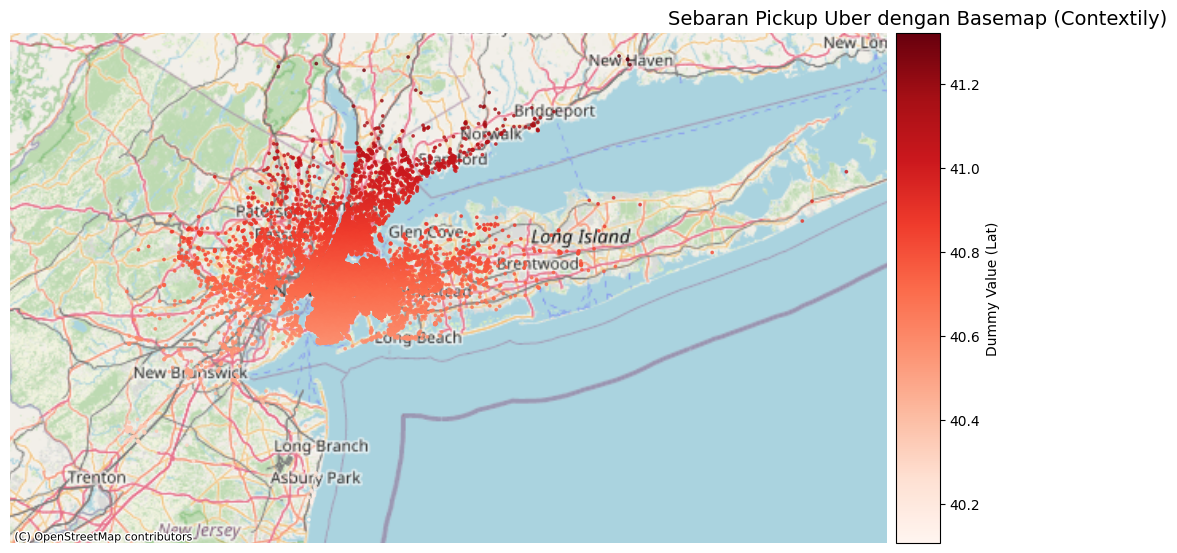

(Base
 B02598    257853
 B02682    220395
 B02617    119308
 B02512     35441
 B02764      9363
 Name: Lat, dtype: int64,
 Base
 B02764      9363
 B02512     35441
 B02617    119308
 B02682    220395
 B02598    257853
 Name: Lat, dtype: int64)

In [24]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from mpl_toolkits.axes_grid1 import make_axes_locatable

np.random.seed(42)
lon_jitter = df['Lon'] + np.random.uniform(-0.002, 0.002, size=len(df))
lat_jitter = df['Lat'] + np.random.uniform(-0.002, 0.002, size=len(df))

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(lon_jitter, lat_jitter),
    crs='EPSG:4326'
)

gdf = gdf.to_crs(epsg=3857)

pickupCount = df.groupby("Base")["Lat"].count()

top_5 = pickupCount.sort_values(ascending=False).head(5)
bottom_5 = pickupCount.sort_values().head(5)

fig, ax = plt.subplots(figsize=(12, 10))

gdf.plot(
    ax=ax,
    column="Lat",
    cmap="Reds",
    markersize=3,
    alpha=0.7,
    legend=False
)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

norm = plt.Normalize(gdf["Lat"].min(), gdf["Lat"].max())
sm = plt.cm.ScalarMappable(cmap="Reds", norm=norm)
sm.set_array([])

plt.colorbar(sm, cax=cax, label="Dummy Value (Lat)")

ax.set_axis_off()

plt.title("Sebaran Pickup Uber dengan Basemap (Contextily)", fontsize=14)
plt.show()

top_5, bottom_5


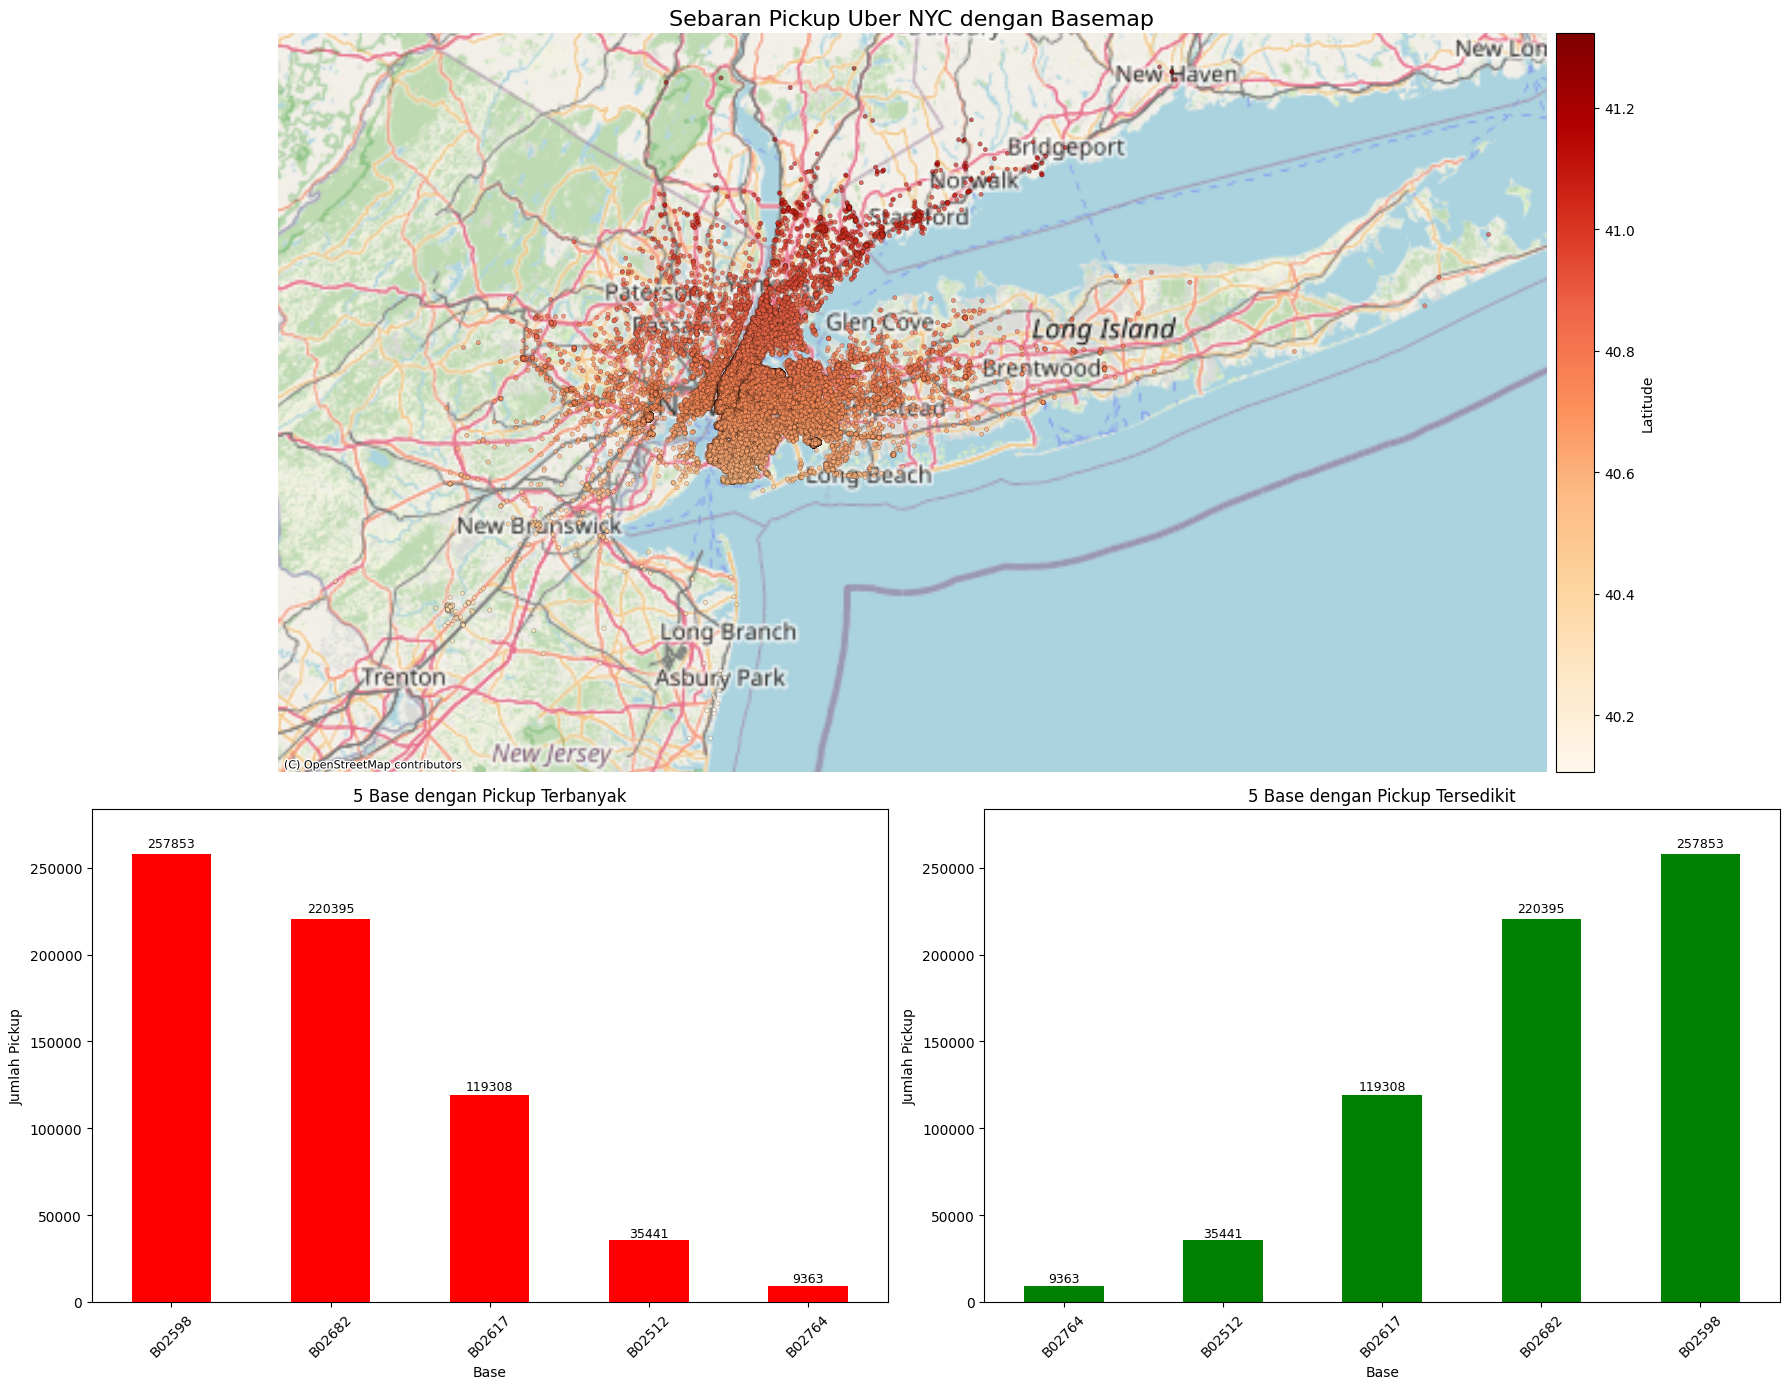

In [25]:
import matplotlib.gridspec as gridspec
pickupCount = df.groupby("Base")["Lat"].count()
top_5 = pickupCount.sort_values(ascending=False).head(5)
bottom_5 = pickupCount.sort_values().head(5)

np.random.seed(42)
lon_jitter = df['Lon'] + np.random.uniform(-0.002, 0.002, size=len(df))
lat_jitter = df['Lat'] + np.random.uniform(-0.002, 0.002, size=len(df))

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(lon_jitter, lat_jitter),
    crs="EPSG:4326"
)

gdf = gdf.to_crs(epsg=3857)

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 2, height_ratios=[3, 2])

ax_map = plt.subplot(gs[0, :])
divider = make_axes_locatable(ax_map)
cax = divider.append_axes("right", size="3%", pad=0.1)

gdf.plot(
    ax=ax_map,
    column="Lat",
    cmap="OrRd",
    legend=True,
    legend_kwds={'label': "Latitude", 'orientation': "vertical"},
    cax=cax,
    markersize=10,
    edgecolor='black',
    linewidth=0.2,
    alpha=0.6
)

ctx.add_basemap(ax_map, source=ctx.providers.OpenStreetMap.Mapnik)
ax_map.set_title("Sebaran Pickup Uber NYC dengan Basemap", fontsize=16)
ax_map.set_axis_off()

ax_top = plt.subplot(gs[1, 0])
top_5.plot(kind='bar', ax=ax_top, color='red')
ax_top.set_title("5 Base dengan Pickup Terbanyak")
ax_top.set_ylabel("Jumlah Pickup")
ax_top.set_xlabel("Base")
ax_top.tick_params(axis='x', rotation=45)

for i, val in enumerate(top_5):
    ax_top.text(i, val + (val * 0.01), f"{val}", ha='center', va='bottom', fontsize=9)

ax_bottom = plt.subplot(gs[1, 1])
bottom_5.plot(kind='bar', ax=ax_bottom, color='green')
ax_bottom.set_title("5 Base dengan Pickup Tersedikit")
ax_bottom.set_ylabel("Jumlah Pickup")
ax_bottom.set_xlabel("Base")
ax_bottom.tick_params(axis='x', rotation=45)

for i, val in enumerate(bottom_5):
    ax_bottom.text(i, val + (val * 0.01), f"{val}", ha='center', va='bottom', fontsize=9)

max_val = max(top_5.max(), bottom_5.max())
ax_top.set_ylim(0, max_val + (max_val * 0.1))
ax_bottom.set_ylim(0, max_val + (max_val * 0.1))

plt.tight_layout()
plt.show()


In [26]:
df.columns

Index(['Date/Time', 'Lat', 'Lon', 'Base'], dtype='object')

In [27]:
from scipy.stats import shapiro

normalityTest_df = df.drop(columns=["Date/Time", "Base"])
normalityTest_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 642360 entries, 0 to 652434
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Lat     642360 non-null  float64
 1   Lon     642360 non-null  float64
dtypes: float64(2)
memory usage: 14.7 MB


In [28]:
from scipy.stats import shapiro

for col in normalityTest_df.columns:
    stat, p = shapiro(normalityTest_df[col])

    print("Kolom:", col)
    print("Statik:", stat)
    print("P-value:", p)

    if p > 0.05:
        print("Data berdistribusi normal (tidak tolak H0)")
    else:
        print("Data tidak berdistribusi normal (tolak H0)")

    print()


Kolom: Lat
Statik: 0.8984282428979371
P-value: 1.743745045793867e-148
Data tidak berdistribusi normal (tolak H0)

Kolom: Lon
Statik: 0.648441380426243
P-value: 5.962019525807473e-191
Data tidak berdistribusi normal (tolak H0)



/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 642360.
  res = hypotest_fun_out(*samples, **kwds)


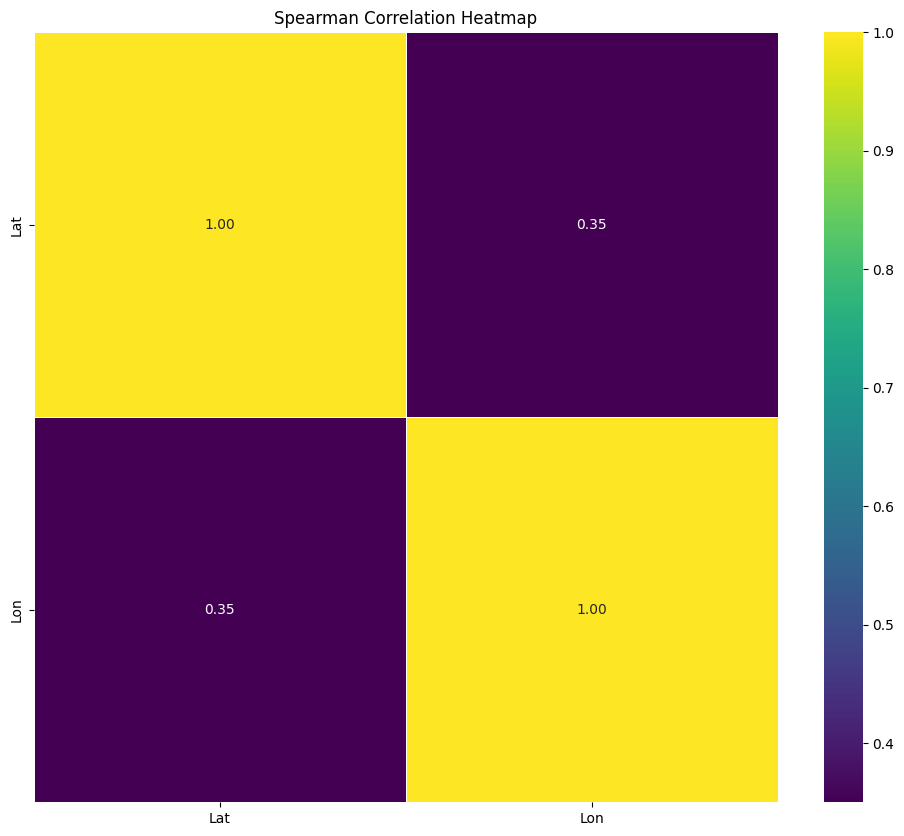

In [29]:
correlation_df = normalityTest_df

correlation_matrix = correlation_df.corr(method='spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title("Spearman Correlation Heatmap")
plt.show()


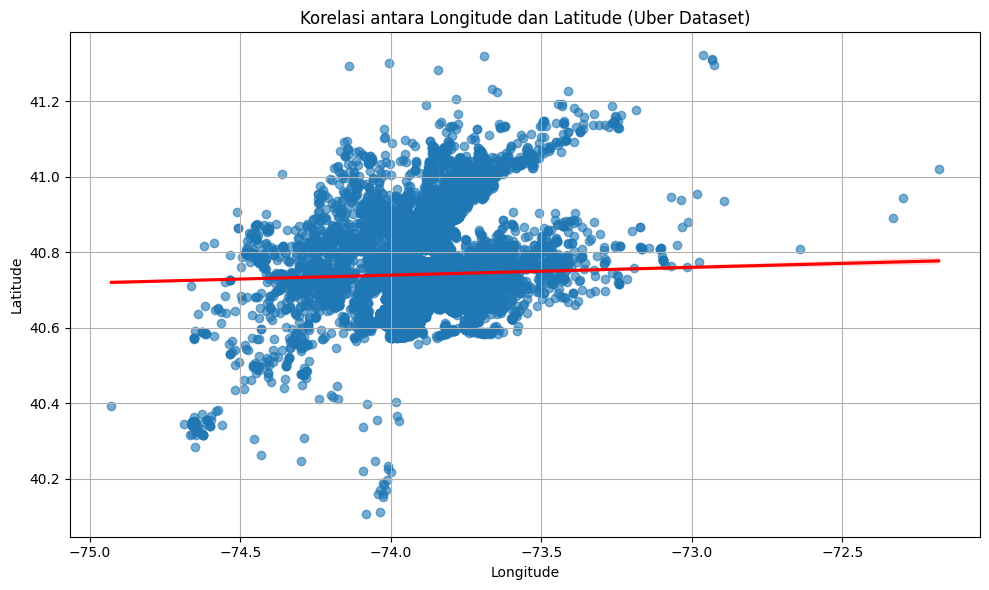

In [30]:
plt.figure(figsize=(10, 6))
sns.regplot(
    x="Lon",
    y="Lat",
    data=df,
    scatter_kws={'alpha': 0.6},
    line_kws={"color": "red"}
)

plt.title("Korelasi antara Longitude dan Latitude (Uber Dataset)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.show()


In [31]:
from sklearn.preprocessing import StandardScaler

normalisasi_df = df.drop(columns=["Date/Time", "Base"])

scaler = StandardScaler()
scaled = scaler.fit_transform(normalisasi_df)

normalisasi_df = pd.DataFrame(scaled, columns=normalisasi_df.columns)
normalisasi_df


,Lat,Lon
0,0.322173,-0.303426
1,-1.161732,0.064716
2,0.170046,-0.162829
3,0.167377,-0.482872
4,0.517002,0.029567
...,...,...
642355,-0.243633,-0.488422
642356,0.340855,-0.088831
642357,-0.646636,0.427308
642358,-1.172408,1.392988


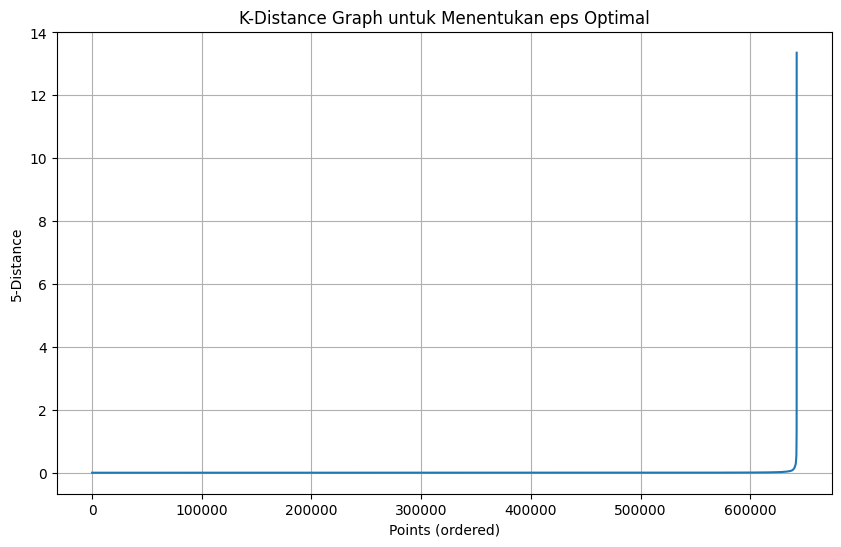

In [32]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

X = normalisasi_df.values
k = 5

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.title("K-Distance Graph untuk Menentukan eps Optimal")
plt.ylabel(f"{k}-Distance")
plt.xlabel("Points (ordered)")
plt.grid(True)
plt.show()
